<a href="https://colab.research.google.com/github/melitjoffy/linear_regression/blob/main/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!apt-get install -y ffmpeg > /dev/null
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

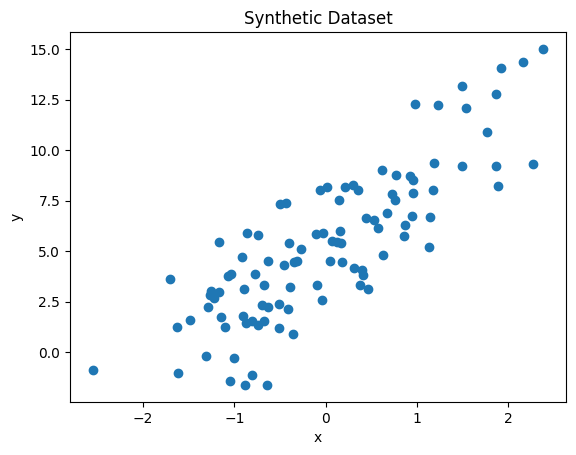

In [4]:
# Set seed for reproducibility
np.random.seed(0)

# Number of data points
n = 100

# Generate random features (2D input)
X = np.random.randn(n, 2)

# True weights and bias
true_w = np.array([3.0, 2.0])
true_b = 5.0

# Generate target values with some noise
y = X @ true_w + true_b + np.random.randn(n) * 0.5

# Plot dataset
plt.plot(X[:, 0], y, 'o')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Synthetic Dataset')
plt.show()

In [5]:
w=np.zeros(2)
b=0.0
lr=0.05
epochs=100

In [7]:
w_history = []
b_history=[]

In [8]:
for epoch in range(epochs):
    y_pred = X @ w + b
    loss = np.mean((y_pred - y) ** 2)

    # gradients
    dw = (2 / n) * X.T @ (y_pred - y)
    db = (2 / n) * np.sum(y_pred - y)

    # update
    w -= lr * dw
    b -= lr * db

    # store
    w_history.append(w.copy())
    b_history.append(b)

In [ ]:
#classification


decision tree

prediction: [0]
class probablities: [[1. 0. 0.]]


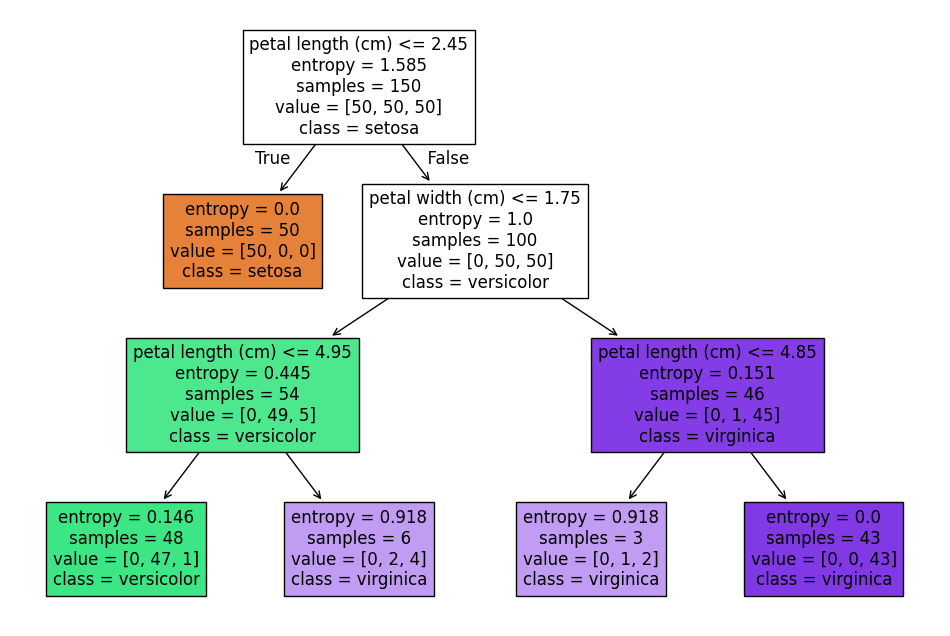

In [5]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier,plot_tree
import matplotlib.pyplot as plt

iris=load_iris()
X,y=iris.data,iris.target
clf=DecisionTreeClassifier(criterion="entropy",max_depth=3,random_state=42)
clf.fit(X,y)
sample=[[5.1,3.5,1.4,0.2,]]
print("prediction:",clf.predict(sample))
print("class probablities:",clf.predict_proba(sample))
plt.figure(figsize=(12,8))
plot_tree(clf,filled=True,feature_names=iris.feature_names,class_names=iris.target_names)
plt.show()

hyperparameter tuning

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   # 20% for testing, 80% for training
    random_state=42, # reproducibility
    stratify=y       # keeps class balance (for classification)
)



param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],   # Corrected here
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=5000),  # ensure convergence
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit on training data
grid_search.fit(X_train, y_train)

# Results
print("✅ Best Parameters:", grid_search.best_params_)
print("📊 Best Cross-Validation Accuracy:", grid_search.best_score_)
print("🏆 Test Accuracy:", grid_search.score(X_test, y_test))


✅ Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'saga'}
📊 Best Cross-Validation Accuracy: 0.975
🏆 Test Accuracy: 1.0


RANDOMIZED SEARCH CV

> Add blockquote



In [10]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

random_search = RandomizedSearchCV(
    estimator=LogisticRegression(max_iter=5000),  # ensure convergence
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

# Fit on training data
random_search.fit(X_train, y_train)

# Results
print("✅ Best Parameters:", random_search.best_params_)
print("📊 Best Cross-Validation Accuracy:", random_search.best_score_)
print("🏆 Test Accuracy:", random_search.score(X_test, y_test))


✅ Best Parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 100}
📊 Best Cross-Validation Accuracy: 0.975
🏆 Test Accuracy: 1.0
